# Jeu de traces simulées à partir d'un réseau

Nous présentons ici un exemple simple et complet reposant sur une collection de traces simulées à partir d’un réseau. 

Ce pipeline est exécuté en une seule itération.

Le réseau est un extrait de la BDTOPO située sur un versant de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons.

## Import des librairies

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

## Données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



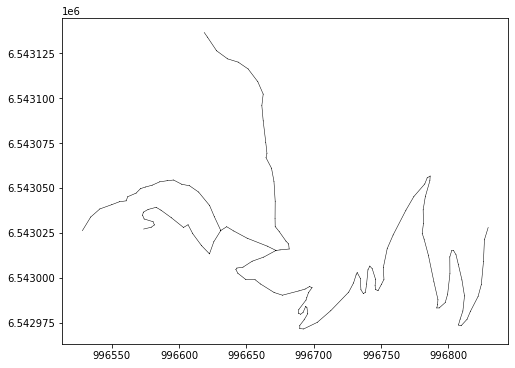

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network2.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (100 of 100) |######################| Elapsed Time: 0:00:01 Time:  0:00:010000


------------------------------------------------------------
88 (88.0 %) tracks generated on network
------------------------------------------------------------


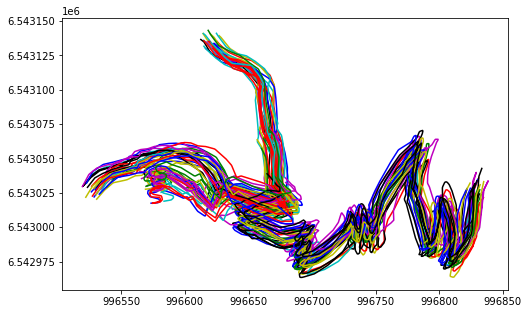

In [3]:
#
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=100, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)
#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

setupenv(RESPATH)


## Step 1 : segment and resample

In [5]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks after segmentation: 88
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  88
    Number of tracks after resampling: 88
    Number of tracks after resampling: 88
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [6]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30

SEUIL_DENSITE = 300  # 15 - 1000
SEUIL_SURFACE = 1000 # m2 - 50000 - 7000

cut_factor = 2

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       prefix='PT', rep='resample_grid', cut_factor=cut_factor)



Starting rasterization and vectorization
    Number of tracks to load:  88
Starting heatmap computation ...
    Execution time (seconds): 0.7105224132537842
    Finished heatmap computation.
Starting morphological opening ...


100% (332 of 332) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (503 of 503) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.22452044486999512
    Finished morphological opening.
Vectorizing ...
    Execution time (seconds): 0.02685999870300293
    Vectorization completed.
Smoothing polygon to remove stair-step artifacts ...
    Execution time (seconds): 0.09082770347595215
    Road surface smoothing completed.
Starting centerline computation ...


100% (678 of 678) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.14229846000671387
    Centerline computed.
Stage 2 completed: rasterization and vectorization.


Text(0.5, 1.0, 'Road surface lissée')

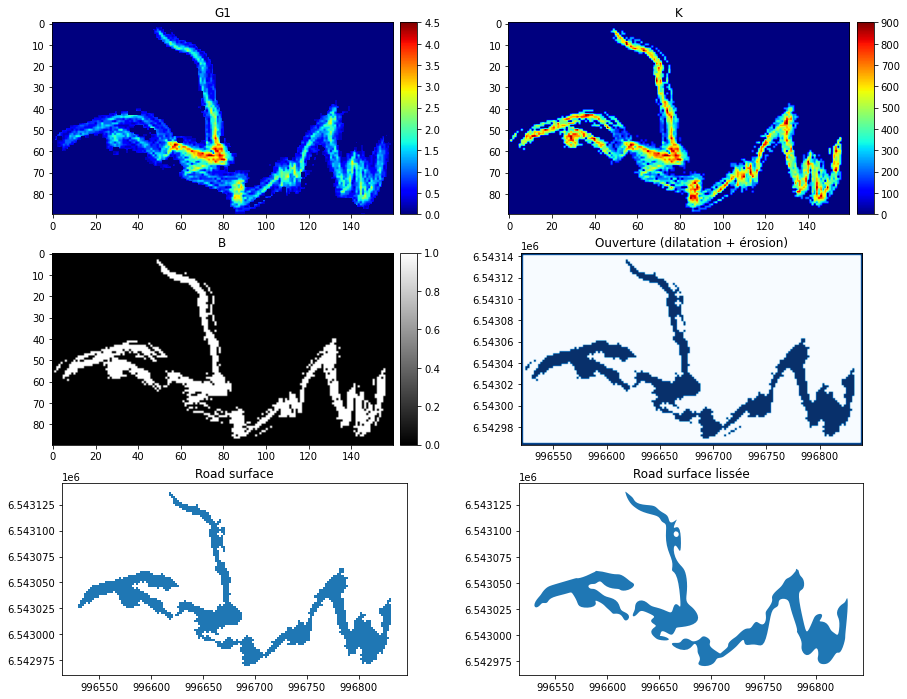

In [7]:
from ofnp import matPlotShapefile, matPlotRaster

plt.figure(figsize=(15, 12))

ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_PT.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', vmin=0, append=ax1)

ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_PT.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_PT.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

# ----------------------------------------------------------------------------------------------------------
import rasterio
from rasterio.plot import show

ax4 = plt.subplot2grid((3, 2), (1, 1))
with rasterio.open(RESPATH + 'image/erosion_PT.tif') as src:
    show(src, ax=ax4, cmap="Blues")  # Greys
ax4.set_title('Ouverture (dilatation + érosion)')

# ----------------------------------------------------------------------------------------------------------
ax5 = plt.subplot2grid((3, 2), (2, 0))
matPlotRaster(RESPATH, 'image/road_surface_PT.shp', ax5)
ax5.set_title('Road surface')

# ----------------------------------------------------------------------------------------------------------
ax6 = plt.subplot2grid((3, 2), (2, 1))
matPlotRaster(RESPATH, 'image/road_surface_lissee_PT.shp', ax6)
ax6.set_title('Road surface lissée')

## Step 3 : création de la center line

In [8]:
from ofnp import addTopologyToNetwork

DIST_MIN_ARC  = 50
addTopologyToNetwork(RESPATH, DIST_MIN_ARC)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_PT.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)

Starting topology creation for the network
    Number of edges in the smoothed skeleton: 295
    Finished loaded skeleton.
Starting topology creation ...
    Execution time (seconds): 0.16467547416687012
    Finished created topology.
Finished removing hooked parts of the skeleton.
Finished simplification of the skeleton.
Stage 3 completed: adding topology to the skeleton.


Text(0.5, 1.0, 'squelette avec topologie et BDTOPO')

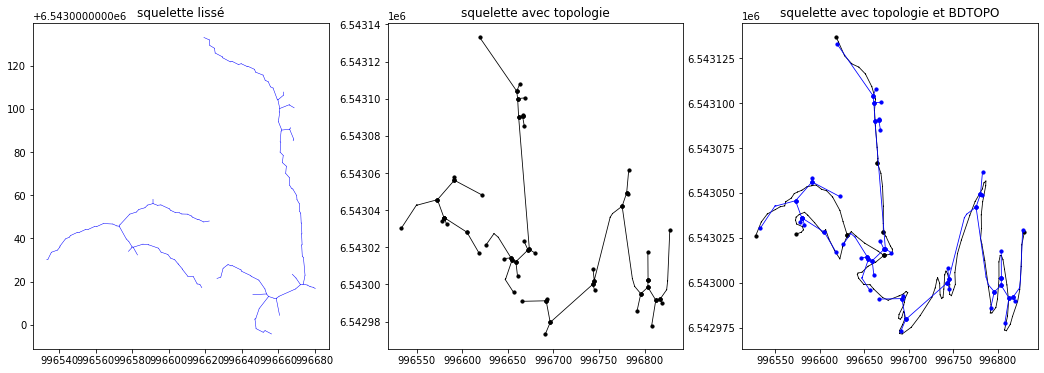

In [9]:
plt.figure(figsize=(18, 6))

ax1 = plt.subplot2grid((1, 3), (0, 0))
matPlotShapefile(RESPATH + 'network/', 'squelette_PT.shp', ax1)
ax1.set_title('squelette lissé')

ax2 = plt.subplot2grid((1, 3), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette avec topologie')

ax3 = plt.subplot2grid((1, 3), (0, 2))
network.plot(edges='k-', nodes='ko', size=0.8, append=ax3)
squelette.plot(edges='b-', nodes='bo', size=0.8, append=ax3)
ax3.set_title('squelette avec topologie et BDTOPO')

## Step 4 : Construction des géométries agrégées pour chaque arc du squelette

1. Attribue les points des traces brutes à chaque arc de la topologie
	Recalage avec l’algorithme de Newson and Krumm (2009)

2. Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie

3. Agrégation des morceaux de traces

4. Conflation des traces fusionnées afin d’obtenir un réseau de mobilité

In [10]:
from ofnp import createNetworkGeom

SEARCH = 25

createNetworkGeom(RESPATH, SEARCH, NB_OBS_MIN, DIST_MAX_2OBS)

100% (56 of 56) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


--------------------------------------------------------------------------------------
 ETAPE 4 :                                                               
   - Attribue les points des traces brutes à chaque arc de la topologie 
   - Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
   - Agrégation des morceaux de traces
   - Conflation des traces fusionnées afin d’obtenir un réseau de mobilité
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Loading network ......
    Number of edges =  52
    Number of nodes =  56
 Longueur du réseau =  783.427742258423
Loading collection of tracks ......
    Number of tracks: 88
Temps d'exécution en s: 0.08155226707458496
Map-matching preparation...
Launching Map-matching ...
Map-matching ended
Temps d'exécution en s: 0.43303823471069336
Map-matching results restructuring completed.


### Visualisation de l'appariement

In [11]:
from ofnp import plotMM

plt.figure(figsize=(15, 10))




<Figure size 1080x720 with 0 Axes>

<Figure size 1080x720 with 0 Axes>